In [1]:
# conda create -n celloracle_env python=3.10
# conda activate celloracle_env
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import glob
import joblib

In [2]:
import celloracle as co
co.__version__

which: no R in (/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/perlbrew/bin:/home/rxr456/perl5/perlbrew/perls/perl-5.32.0/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home/rxr456/perl5/bin:/home

'0.20.0'

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold','axes.linewidth':2,'savefig.dpi': 300})
# plt.rcParams['figure.figsize'] = [6, 4.5]
# plt.rcParams["savefig.dpi"] = 300
save_folder = "figures"
os.makedirs(save_folder, exist_ok=True)

In [4]:
storage =  '/mnt/vstor/SOM_PATH_DKB50/members/rxr456/Trapecar_oracle'
os.chdir(storage)

In [5]:
links = joblib.load("oracle_ptime_CD8PBTeff2LTRM_links.pkl")

In [6]:
oracle_ptime_CD8PBTeff2LTRM = co.load_hdf5("CD8PBTeff2LTRM.celloracle.oracle")

In [7]:
base_GRN = co.data.load_human_promoter_base_GRN()

Loading prebuilt promoter base-GRN. Version: hg19_gimmemotifsv5_fpr2


In [10]:
adata = sc.read_h5ad("250307_gut_liver_blood_ultimate_annotated.h5ad")
# adata_ab = sc.read_h5ad("250721_gut_liver_TRM_adata_abTCR_conga.h5ad")

In [6]:
# downsample, not sure, we might just focus on the pseudotime group
# n_cells_downsample = 30000
# sc.pp.subsample(adata, n_obs=n_cells_downsample, random_state=123)

In [12]:
adata_TCR = adata[adata.obs['chain_pairing'].isin(["single pair", "extra VJ","extra VDJ","two full chains"]),:]
adata_ab = adata_TCR[adata_TCR.obs['general type'].isin(['TCRab CD4','TCRab CD8aa','TCRab CD8ab']),:]
adata_ab.obs['clone_code'] = adata_ab.obs['TRAV'].astype(str).map(str)+' '+adata_ab.obs['TRBV'].astype(str).map(str)+' '+adata_ab.obs['cdr3a'].astype(str).map(str)+' '+ adata_ab.obs['cdr3b'].astype(str).map(str)

In [13]:
clone_df = adata_ab.obs[[ 'batch','TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr3a', 'cdr3b','clone_code']]
clone_counts = clone_df.groupby(['batch','clone_code']).size().reset_index(name='clone_size')
clone_counts[['TRAV','TRBV','cdr3a','cdr3b']] = clone_counts['clone_code'].str.split(' ', expand=True)
clone_replace_dict = clone_counts['clone_code'].drop_duplicates().reset_index().set_index('clone_code')['index'].to_dict()
clone_counts['clone_code'] = clone_counts['clone_code'].replace(clone_replace_dict)
clone_counts['clone_code'] = 'clonotype'+clone_counts['clone_code'].astype(str).map(str)
clone_counts

,batch,clone_code,clone_size,TRAV,TRBV,cdr3a,cdr3b
0,3,clonotype0,1,TRAV1-1,TRBV10-2,CAGDNYGQNFVF,CASRAGGVTEAFF
1,3,clonotype1,1,TRAV1-1,TRBV10-2,CAVRDQLPAGKSTF,CASRGGGGNNEQFF
2,3,clonotype2,0,TRAV1-1,TRBV10-2,CAVREGSSNTGKLIF,CASSDPSGAKEETQYF
3,3,clonotype3,1,TRAV1-1,TRBV10-3,CAGGGSAAGNKLTF,CAISERPGTENEKLFF
4,3,clonotype4,1,TRAV1-1,TRBV10-3,CAGMDSNYQLIW,CAISDDRGHRNYGYTF
...,...,...,...,...,...,...,...
56416,5,clonotype18802,0,TRAV9-2,TRBV9,CALSPYNFNKFYF,CASSVEVVPHEQYF
56417,5,clonotype18803,0,TRAV9-2,TRBV9,CALSSNQAGTALIF,CASSMDRGHNEQFF
56418,5,clonotype18804,0,TRAV9-2,TRBV9,CALSTLDSSYKLIF,CASSVEGSGGPNIQYF
56419,5,clonotype18805,0,TRAV9-2,TRBV9,CALYTGGFKTIF,CASSVSGLAGGSYNEQFF


In [14]:
adata_ab.obs['clone_id'] = adata_ab.obs['clone_code'].replace(clone_replace_dict)

In [15]:
adata3 = adata_ab[adata_ab.obs['batch'] == '3',:]
adata4 = adata_ab[adata_ab.obs['batch'] == '4',:]
adata5 = adata_ab[adata_ab.obs['batch'] == '5',:]
adatas=[adata3,adata4,adata5]

In [ ]:
# this is eseentially a quick tool to check the top overlapping patterns of TCRab CD8ab cells
all_cells = []
for i in range(0,3):
    gtype = 'TCRab CD8ab'
    adata_temp = adatas[i][adatas[i].obs['general type']== gtype,:]
    df = adata_temp.obs[['tissue+celltype','clone_id']]
    clone_migrations = df.groupby(['clone', 'tissue+celltype']).size().unstack().fillna(0)
    
    clone_migrations_pattern = clone_migrations>0
    clone_migrations_pattern = clone_migrations_pattern.astype(int)
    clone_migrations = clone_migrations_pattern.loc[clone_migrations_pattern.apply(sum, axis=1)>2,:]
    
    clone_migrations['pattern'] = clone_migrations.apply(tuple, axis=1)

    # Step 2: Count occurrences of each unique pattern
    pattern_counts = clone_migrations['pattern'].value_counts()

    # Step 3: Sort by frequency (this is done by value_counts automatically)
    pattern_ranking = pattern_counts.reset_index()
    pattern_ranking.columns = ['pattern', 'frequency']

    # Display the ranking
    # print_full(list(clone_migrations_pattern.columns))
    print(pattern_ranking)

In [28]:
all_cells = []
for i in range(0,3):
    gtype = 'TCRab CD4'
    adata_temp = adatas[i][adatas[i].obs['general type']== gtype,:]
    df = adata_temp.obs[['tissue+celltype','clone_id']]
    clone_migrations = df.groupby(['clone_id', 'tissue+celltype']).size().unstack().fillna(0)
    shared_clones = clone_migrations.index[(clone_migrations['L TCRab CD4 TRM'] >0) & (clone_migrations['LP TCRab CD4 TRM'] >0) & (clone_migrations['IEL TCRab CD4 TRM'] >0) ]
    #sum_clones = clone_migrations.loc[shared_clones,:].sum(axis = 0)
    #print(sum_clones[sum_clones!=0])
    
    cell_ids = adata_temp.obs_names[adata_temp.obs['clone_id'].isin(shared_clones)].tolist()
    for j in cell_ids:
        all_cells.append(j)

adata_ptime_test = adata_ab[(adata_ab.obs_names.isin(all_cells))&(adata_ab.obs['tissue+celltype'].isin(['L TCRab CD4 TRM','LP TCRab CD4 TRM','IEL TCRab CD4 TRM'])),:]
adata_ptime_test

View of AnnData object with n_obs × n_vars = 106 × 27525
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'clone_code', 'clone_id'
    uns: 'Donor ID_colors', 'celltype w', 'celltype_colors', 'general type_colors', 'major celltype pl_colors', 'major celltype_colors', 'neighbors', 'paga', 'tissue_colors', 'tissue_sizes', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp

In [17]:
adata_ptime_CD8PBTeff2LTRM = adata_ab[adata_ab.obs['tissue+celltype'].isin(['L TCRab CD8ab TRM','L TCRab CD8ab Teff','PB TCRab CD8ab Teff']),:]
adata_ptime_CD8PBTeff2LTRM

View of AnnData object with n_obs × n_vars = 3337 × 27525
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'clone_code', 'clone_id'
    uns: 'Donor ID_colors', 'celltype w', 'celltype_colors', 'general type_colors', 'major celltype pl_colors', 'major celltype_colors', 'neighbors', 'paga', 'tissue_colors', 'tissue_sizes', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obs

In [18]:
adata_ptime_IELLPLCD4TRM = adata_ab[adata_ab.obs['tissue+celltype'].isin(['L TCRab CD4 TRM','IEL TCRab CD4 TRM','LP TCRab CD4 TRM']),:]
adata_ptime_IELLPLCD4TRM

View of AnnData object with n_obs × n_vars = 5377 × 27525
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'clone_code', 'clone_id'
    uns: 'Donor ID_colors', 'celltype w', 'celltype_colors', 'general type_colors', 'major celltype pl_colors', 'major celltype_colors', 'neighbors', 'paga', 'tissue_colors', 'tissue_sizes', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obs

also load our in silico perturbation targets

In [19]:
donor_files = glob.glob("Donor*h5ad")
print(donor_files)
print([i.replace(' ','_') for i in donor_files])

['Donor AJG2309 L TCRab CD8ab TRM.h5ad', 'Donor AJKQ118 IEL TCRab CD8ab TRM.h5ad', 'Donor AJKQ118 L TCRab CD4 TRM.h5ad', 'Donor AJKQ118 L TCRab CD8ab TRM.h5ad']
['Donor_AJG2309_L_TCRab_CD8ab_TRM.h5ad', 'Donor_AJKQ118_IEL_TCRab_CD8ab_TRM.h5ad', 'Donor_AJKQ118_L_TCRab_CD4_TRM.h5ad', 'Donor_AJKQ118_L_TCRab_CD8ab_TRM.h5ad']


In [20]:
Donor_AJG2309_L_TCRab_CD8ab_TRM = sc.read_h5ad("Donor AJG2309 L TCRab CD8ab TRM.h5ad")
Donor_AJKQ118_IEL_TCRab_CD8ab_TRM = sc.read_h5ad("Donor AJKQ118 IEL TCRab CD8ab TRM.h5ad")
Donor_AJKQ118_L_TCRab_CD4_TRM = sc.read_h5ad("Donor AJKQ118 L TCRab CD4 TRM.h5ad")
Donor_AJKQ118_L_TCRab_CD8ab_TRM = sc.read_h5ad("Donor AJKQ118 L TCRab CD8ab TRM.h5ad")

### I will just let this running while I am sleeping

27525 genes were found in the adata. Note that Celloracle is intended to use around 1000-3000 genes, so the behavior with this number of genes may differ from what is expected.


... storing 'clone_code' as categorical


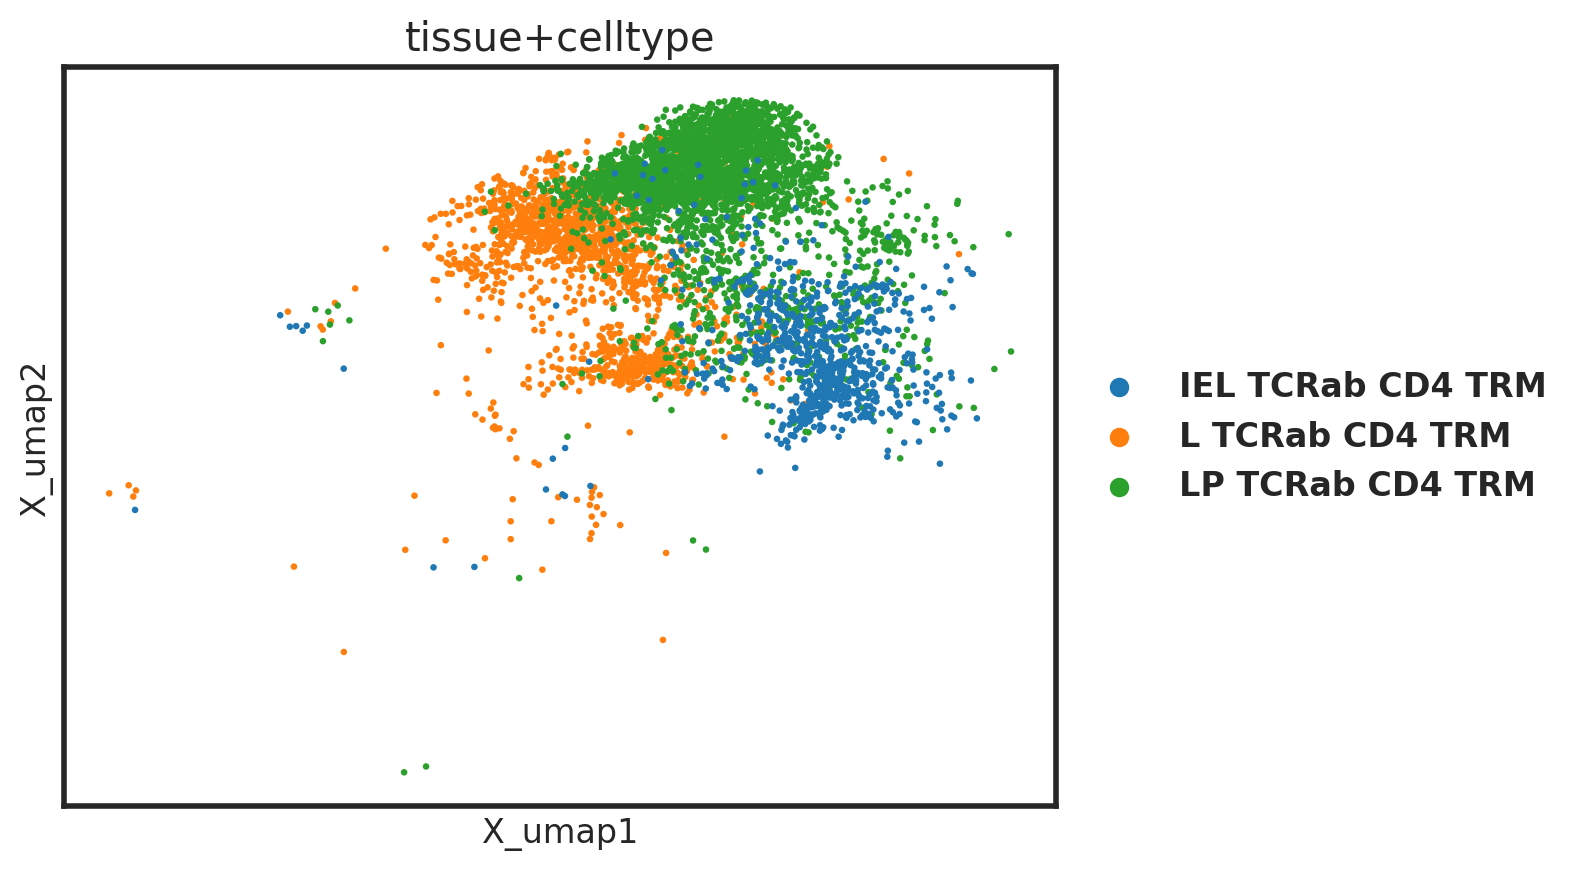

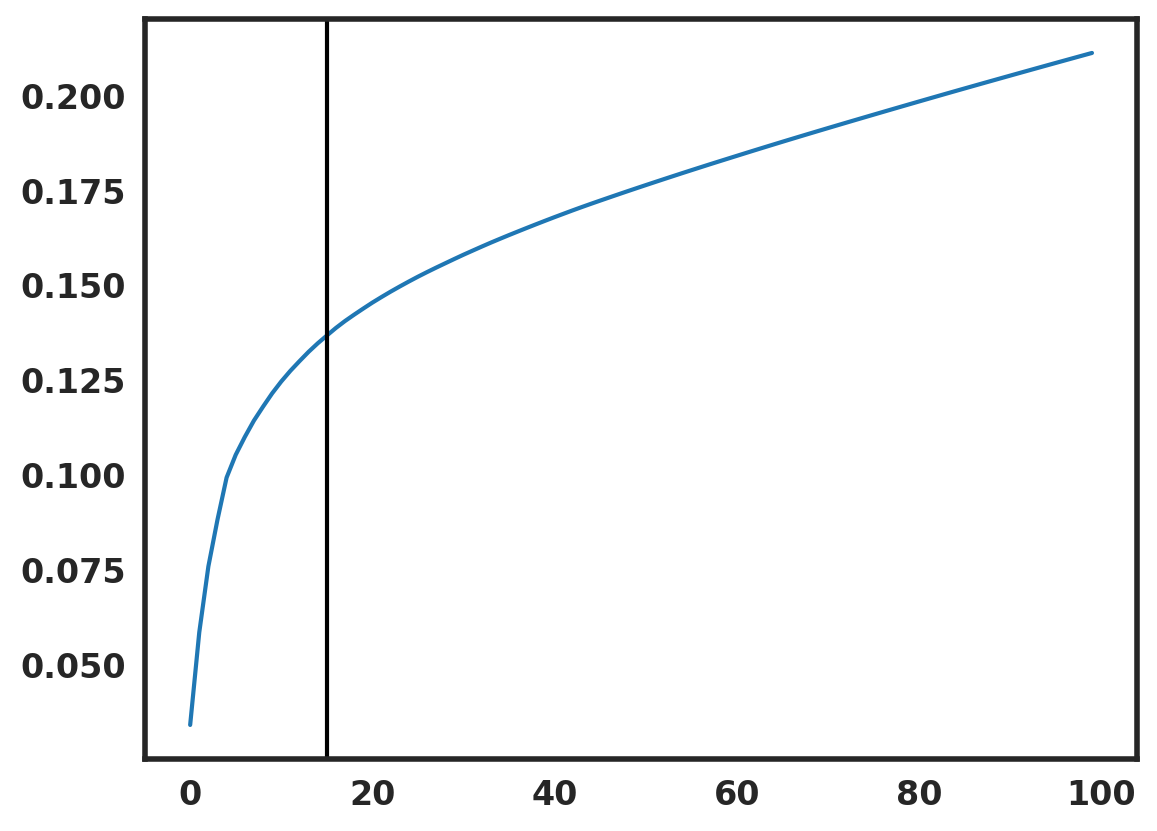

15
cell number is :5377
Auto-selected k is :134


  0%|          | 0/3 [00:00<?, ?it/s]

Inferring GRN for IEL TCRab CD4 TRM...


  0%|          | 0/18822 [00:00<?, ?it/s]

Inferring GRN for L TCRab CD4 TRM...


  0%|          | 0/18822 [00:00<?, ?it/s]

Inferring GRN for LP TCRab CD4 TRM...


  0%|          | 0/18822 [00:00<?, ?it/s]

AttributeError: 'Oracle' object has no attribute 'save_hdf5'

In [ ]:
adata_list = [adata_ptime_IELLPLCD4TRM, Donor_AJG2309_L_TCRab_CD8ab_TRM, Donor_AJKQ118_IEL_TCRab_CD8ab_TRM, Donor_AJKQ118_L_TCRab_CD4_TRM, Donor_AJKQ118_L_TCRab_CD8ab_TRM]
file_prefix = ['adata_ptime_IELLPLCD4TRM', 'Donor_AJG2309_L_TCRab_CD8ab_TRM', 'Donor_AJKQ118_IEL_TCRab_CD8ab_TRM', 'Donor_AJKQ118_L_TCRab_CD4_TRM', 'Donor_AJKQ118_L_TCRab_CD8ab_TRM']
for i, every_adata in enumerate(adata_list):
    oracle_temp = co.Oracle()
    every_adata.X = every_adata.layers['counts'].copy()
    oracle_temp.import_anndata_as_raw_count(adata=every_adata,
                                   cluster_column_name="tissue+celltype",
                                   embedding_name="X_umap" )
    oracle_temp.import_TF_data(TF_info_matrix=base_GRN)
    oracle_temp.perform_PCA()

    # Select important PCs
    plt.plot(np.cumsum(oracle_temp.pca.explained_variance_ratio_)[:100])
    n_comps = np.where(np.diff(np.diff(np.cumsum(oracle_temp.pca.explained_variance_ratio_))>0.002))[0][0]
    plt.axvline(n_comps, c="k")
    plt.show()
    print(n_comps)
    n_comps = min(n_comps, 50)

    n_cell = oracle_temp.adata.shape[0]
    print(f"cell number is :{n_cell}")
    k = int(0.025*n_cell)
    print(f"Auto-selected k is :{k}")
    oracle_temp.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                        b_maxl=k*4, n_jobs=4)
    oracle_temp.to_hdf5(f"{file_prefix[i]}.celloracle.oracle")
    links = oracle_temp.get_links(cluster_name_for_GRN_unit="tissue+celltype", alpha=10,
                         verbose_level=10)
    joblib.dump(links, f"{file_prefix[i]}_links.pkl")
    oracle_temp.to_hdf5(f"{file_prefix[i]}.celloracle.oracle")

### Start from adata_ptime_CD8PBTeff2LTRM

... storing 'clone_code' as categorical


27525 genes were found in the adata. Note that Celloracle is intended to use around 1000-3000 genes, so the behavior with this number of genes may differ from what is expected.


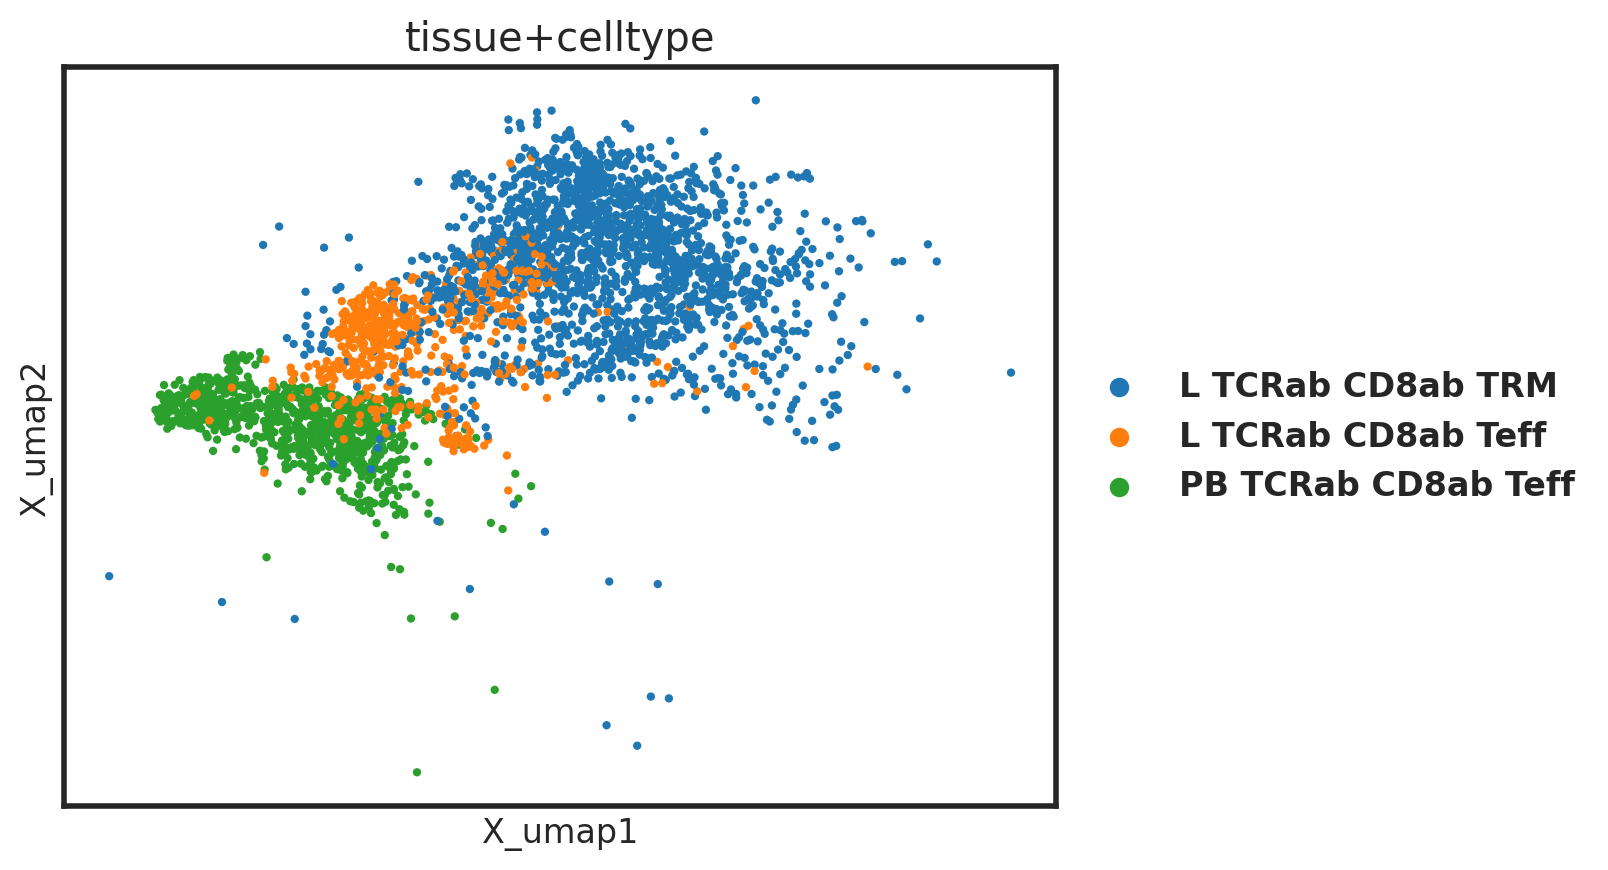

In [42]:
oracle_ptime_CD8PBTeff2LTRM = co.Oracle()
adata_ptime_CD8PBTeff2LTRM.X =adata_ptime_CD8PBTeff2LTRM.layers['counts'].copy()
oracle_ptime_CD8PBTeff2LTRM.import_anndata_as_raw_count(adata=adata_ptime_CD8PBTeff2LTRM,
                                   cluster_column_name="tissue+celltype",
                                   embedding_name="X_umap")

In [43]:
oracle_ptime_CD8PBTeff2LTRM.import_TF_data(TF_info_matrix=base_GRN)

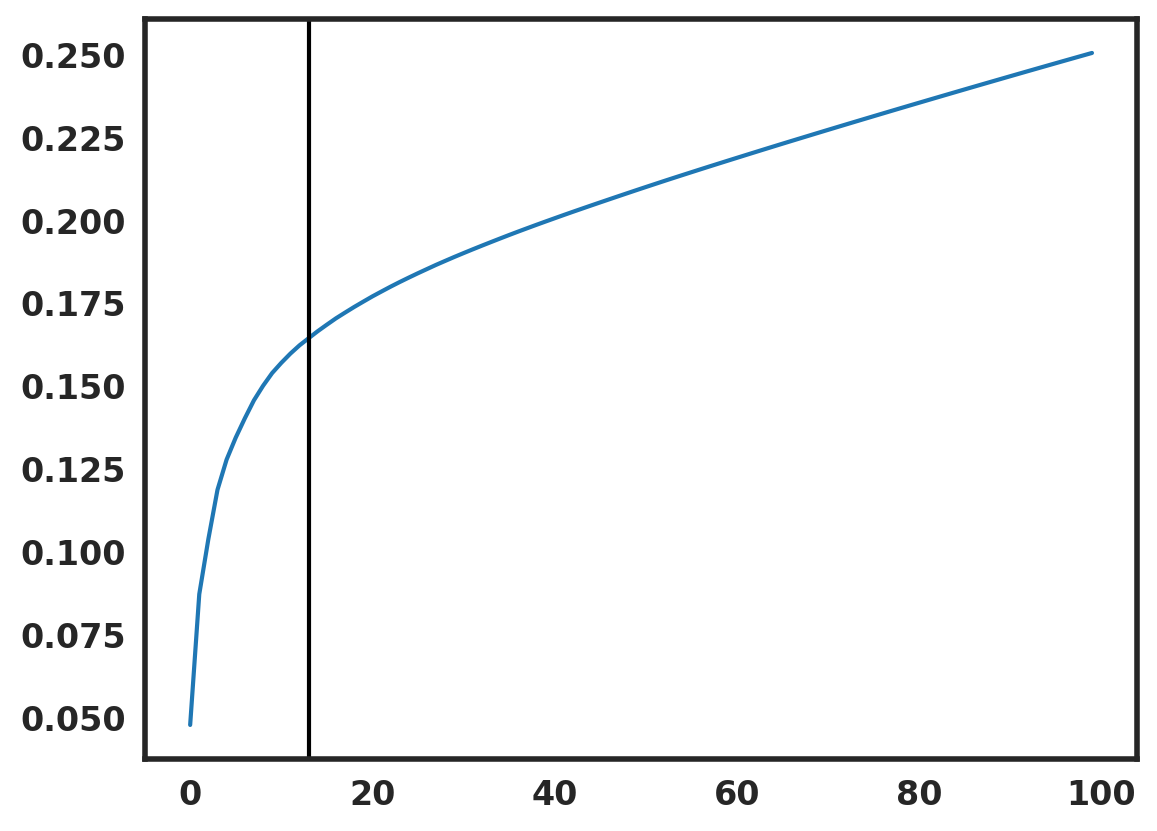

13


In [44]:
oracle_ptime_CD8PBTeff2LTRM.perform_PCA()

# Select important PCs
plt.plot(np.cumsum(oracle_ptime_CD8PBTeff2LTRM.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle_ptime_CD8PBTeff2LTRM.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k")
plt.show()
print(n_comps)
n_comps = min(n_comps, 50)

In [45]:
n_cell = oracle_ptime_CD8PBTeff2LTRM.adata.shape[0]
print(f"cell number is :{n_cell}")

cell number is :3337


In [46]:
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")

Auto-selected k is :83


In [47]:
oracle_ptime_CD8PBTeff2LTRM.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8,
                      b_maxl=k*4, n_jobs=4)

In [19]:
oracle_ptime_CD8PBTeff2LTRM.to_hdf5("CD8PBTeff2LTRM.celloracle.oracle")

In [50]:
oracle_ptime_CD8PBTeff2LTRM.adata

AnnData object with n_obs × n_vars = 3337 × 27525
    obs: 'has_ir', 'chain_pairing', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'cdr1a', 'cdr2a', 'cdr3a', 'cdr1b', 'cdr2b', 'cdr3b', 'n_counts', 'n_genes', 'mt_frac', 'ribo_frac', 'batch', 'S_score', 'G2M_score', 'S_G2M_diff', 'phase', 'leiden', 'has_ir_q', 'cluster_blind', 'general type', 'activation', 'tissue', 'general subtype', 'celltype', 'cluster+celltype', 'tissue+cluster+celltype', 'celltype w/ activation', 'major celltype', 'major general subtype', 'Donor ID', 'tissue+celltype', 'major celltype pl', 'tissue+celltype w/ activation', 'cluster+celltype w/ activation', 'tissue+cluster+celltype w/ activation', 'act_score', 'donor+tissue+celltype w/ activation', 'clone_code', 'clone_id'
    var: 'symbol', 'isin_top1000_var_mean_genes', 'isin_TFdict_targets', 'isin_TFdict_regulators'
    uns: 'Donor ID_colors', 'celltype w', 'celltype_colors', 'general type_colors', 'major celltype pl_colors', 'major celltype_colors', 'neighbors', 'paga', 'tissu

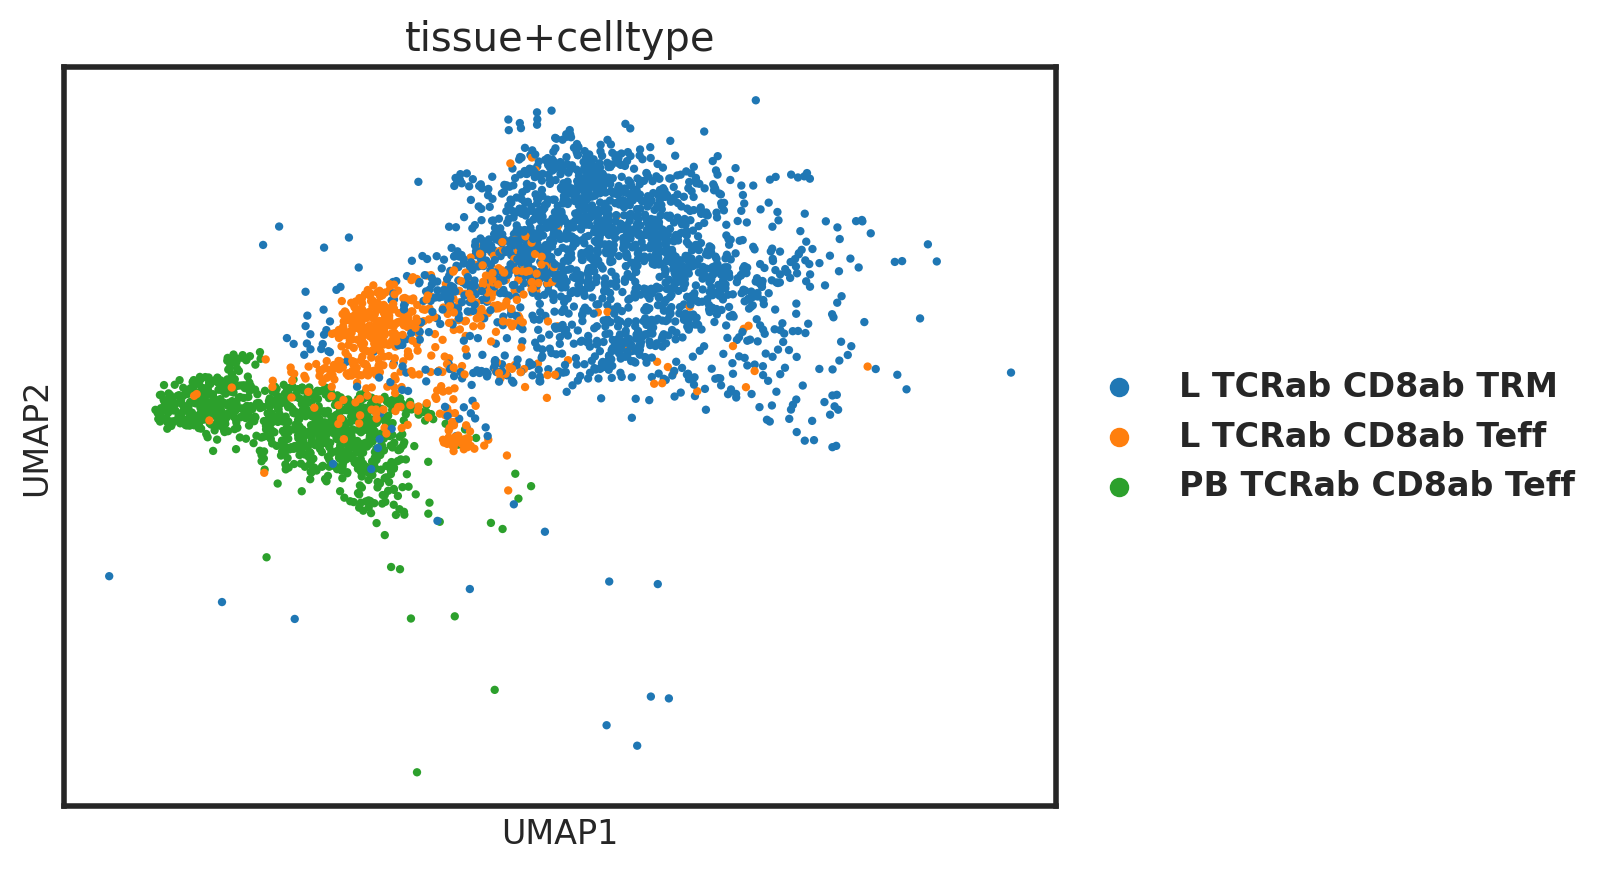

In [51]:
sc.pl.umap(oracle_ptime_CD8PBTeff2LTRM.adata, color="tissue+celltype")

In [52]:
links = oracle_ptime_CD8PBTeff2LTRM.get_links(cluster_name_for_GRN_unit="tissue+celltype", alpha=10,
                         verbose_level=10)

  0%|          | 0/3 [00:00<?, ?it/s]

Inferring GRN for L TCRab CD8ab TRM...


  0%|          | 0/18822 [00:00<?, ?it/s]

Inferring GRN for L TCRab CD8ab Teff...


  0%|          | 0/18822 [00:00<?, ?it/s]

Inferring GRN for PB TCRab CD8ab Teff...


  0%|          | 0/18822 [00:00<?, ?it/s]

In [ ]:
joblib.dump(links, "oracle_ptime_CD8PBTeff2LTRM_links.pkl")

['oracle_ptime_CD8PBTeff2LTRM_links.pkl']

In [9]:
links.links_dict["L TCRab CD8ab TRM"]

,source,target,coef_mean,coef_abs,p,-logp
0,THAP1,A1BG,-0.001550,0.001550,1.302449e-03,2.885239
1,ZIC1,A1BG,0.000000,0.000000,NaN,-0.000000
2,ZEB1,A1BG,0.010116,0.010116,2.905356e-07,6.536801
3,USF1,A1BG,-0.000784,0.000784,3.914957e-02,1.407273
4,STAT4,A1BG,0.004405,0.004405,3.986805e-04,3.399375
...,...,...,...,...,...,...
2635813,PKNOX1,ZZEF1,-0.003265,0.003265,2.823153e-08,7.549266
2635814,TGIF1,ZZEF1,-0.000782,0.000782,2.367775e-02,1.625660
2635815,NR3C1,ZZEF1,-0.003533,0.003533,1.163493e-05,4.934236
2635816,SPDEF,ZZEF1,0.000000,0.000000,NaN,-0.000000


In [10]:
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)

L TCRab CD8ab TRM


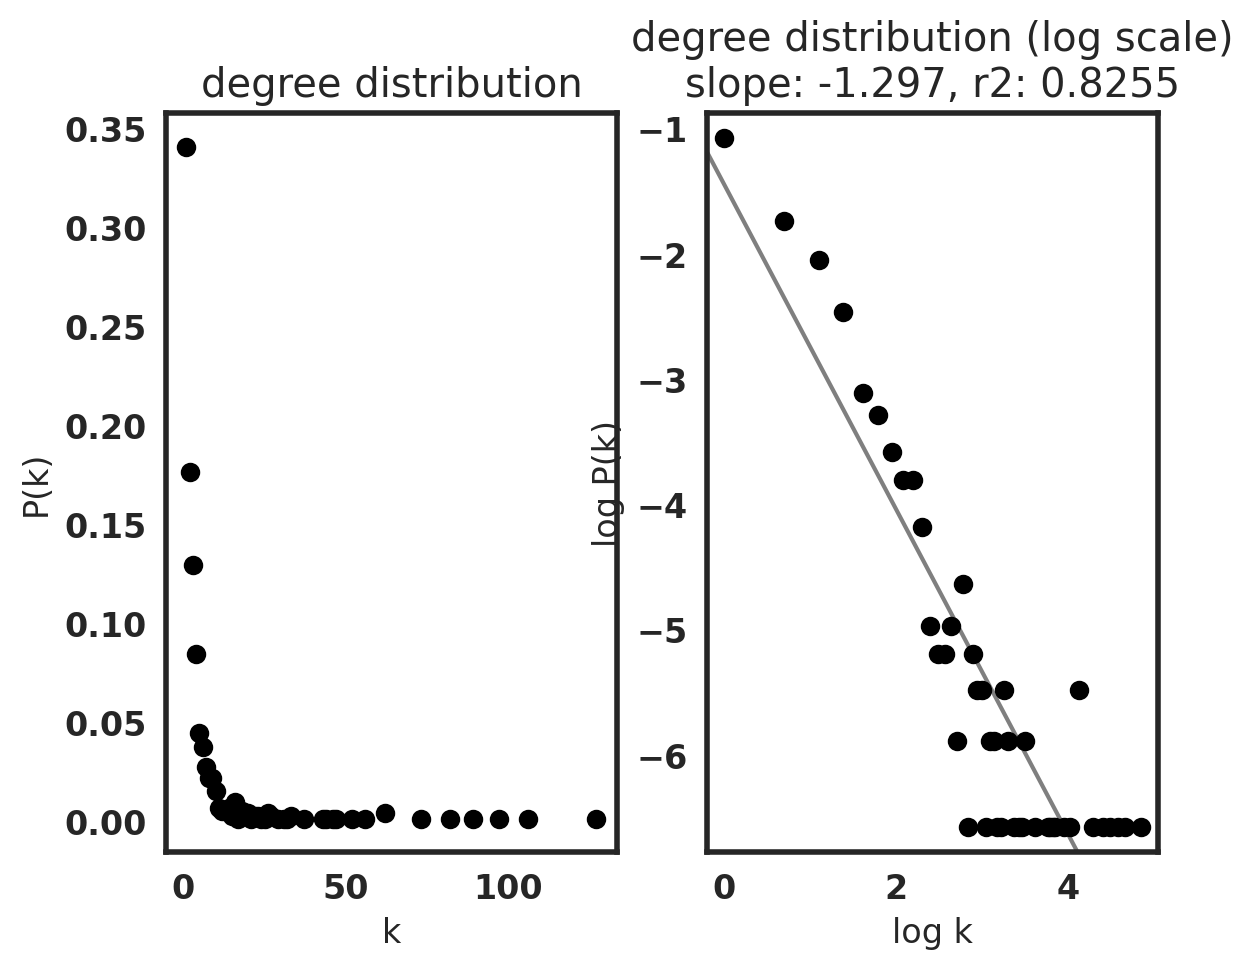

L TCRab CD8ab Teff


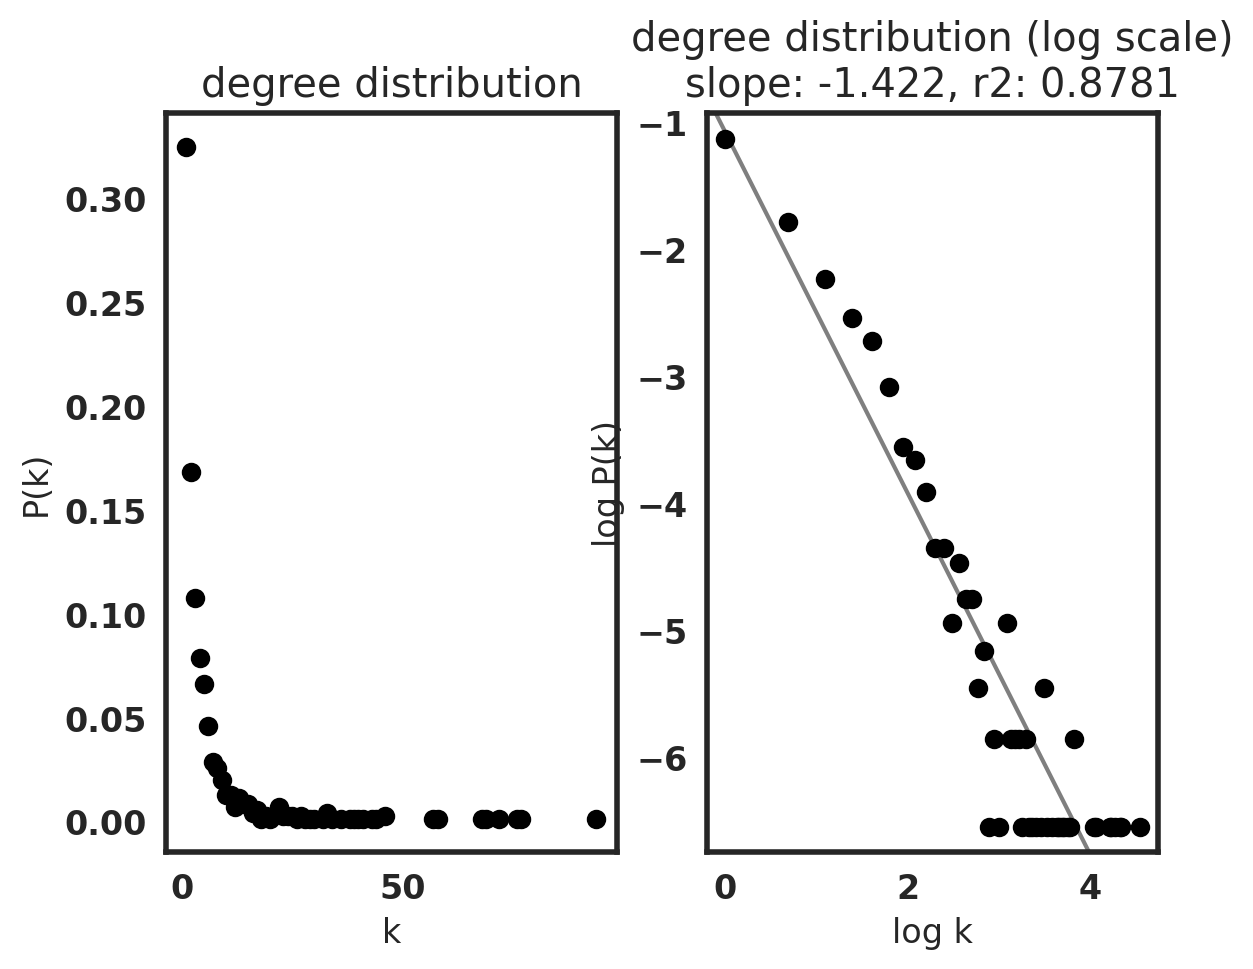

PB TCRab CD8ab Teff


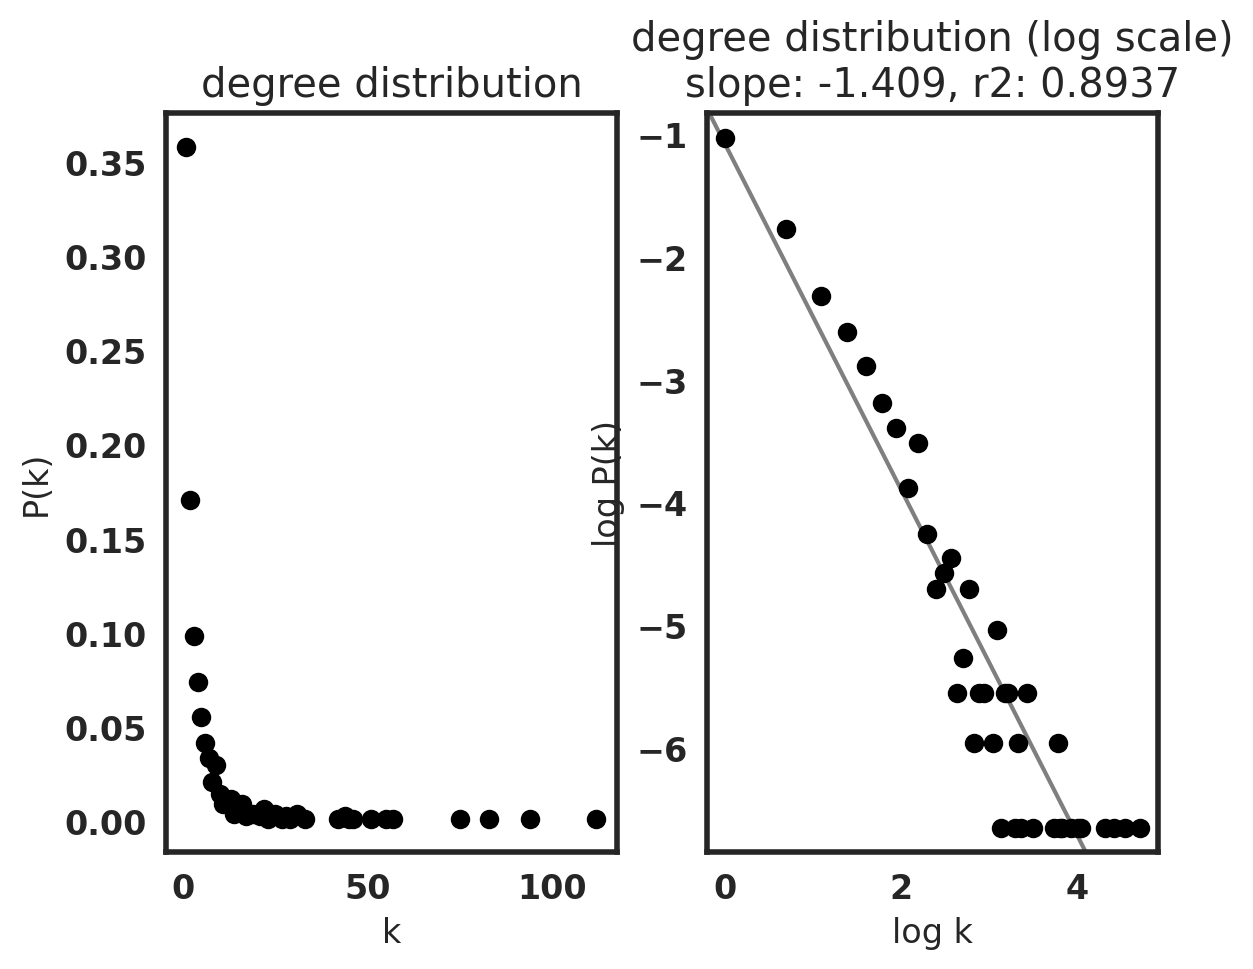

In [11]:
links.plot_degree_distributions(plot_model=True,
                                               #save=f"{save_folder}/degree_distribution/",
                                               )

In [16]:
links.get_network_score()

In [17]:
links.merged_score.head()

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
JUNB,56,0.077994,15,0.020891,41,0.057103,3893.0,0.735813,L TCRab CD8ab TRM
JUN,54,0.075209,7,0.009749,47,0.065460,5191.0,0.709106,L TCRab CD8ab TRM
FOS,100,0.139276,16,0.022284,84,0.116992,6466.0,1.000000,L TCRab CD8ab TRM
DUSP1,6,0.008357,6,0.008357,0,0.000000,0.0,0.330511,L TCRab CD8ab TRM
CREM,26,0.036212,4,0.005571,22,0.030641,1484.0,0.158398,L TCRab CD8ab TRM


In [14]:
joblib.dump(links, "oracle_ptime_CD8PBTeff2LTRM_links.pkl")

['oracle_ptime_CD8PBTeff2LTRM_links.pkl']

In [18]:
links.filter_links()
oracle_ptime_CD8PBTeff2LTRM.get_cluster_specific_TFdict_from_Links(links_object=links)
oracle_ptime_CD8PBTeff2LTRM.fit_GRN_for_simulation(alpha=10,
                              use_cluster_specific_TFdict=True)

  0%|          | 0/3 [00:00<?, ?it/s]